In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re

sns.set_style("whitegrid")

# Utility functions

In [44]:
def print_regression_metrics(y_true, y_pred):
    """Calculates and prints MSE, RMSE, R^2, and SSE for given true and predicted values."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Sum of Squared Errors (SSE)
    sse = np.sum((y_true - y_pred) ** 2)

    # Mean Squared Error (MSE)
    mse = np.mean((y_true - y_pred) ** 2)

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mse)

    # R-squared (R^2)
    SST = np.sum((y_true - np.mean(y_true)) ** 2)
    SSR = SST - sse
    r2 = SSR/SST

    print(f"SST  : {SST:.4f}")
    print(f"SSE  : {sse:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


def calculate_correlation(data, p):
    corr_name = set()
    corr = data.corr()
    df_corr = pd.DataFrame(corr)
    highly_correlated_cols = np.where(np.abs(df_corr) > p) # for P & N ,regardless direction
    highly_positive_correlated_cols = np.where(df_corr > p) # only for positive
    highly_negative_correlated_cols = np.where(df_corr < -p) # only for negative
    for i,j in zip(*highly_correlated_cols):
        if i != j:
            corr_name.add(i)
            corr_name.add(j)
    print("Highly correlated columns:")
    for h in corr_name:
        print(f"{df_corr.columns[h]}")

    return corr_name

def createDF(cv_res, exp_name):
    rows = []
    for model_name, metrics in cv_res.items():
        row = {"Experiment": exp_name, "Model": model_name}
        for metric_name, values in metrics.items():
            row[f"{metric_name}_mean"] = values.mean()
            row[f"{metric_name}_std"] = values.std()
        rows.append(row)

    summary_df = pd.DataFrame(rows).set_index(["Experiment", "Model"])
    summary_df = summary_df.sort_values("RMSE_mean")

    df = pd.DataFrame({
        "SSE": summary_df.apply(lambda r: f"{r['SSE_mean']:,.2e} ± {r['SSE_std']:,.2e}", axis=1),
        "RMSE": summary_df.apply(lambda r: f"{r['RMSE_mean']:,.4f} ± {r['RMSE_std']:,.4f}", axis=1),
        "R2": summary_df.apply(lambda r: f"{r['R2_mean']:.4f} ± {r['R2_std']:.4f}", axis=1),
    })
    return df

def plot_cv_res(exp1, exp2):
    fig, ax = plt.subplots(1,2, figsize=(16, 8))
    data1 = [metrics["R2"] for metrics in exp1.values()]
    data2 = [metrics["R2"] for metrics in exp2.values()]

    ax[0].boxplot(data1, tick_labels=exp1.keys())
    ax[0].set_ylabel("R2")
    ax[0].set_title("R2 across 5-fold CV ,(Normal y)")

    ax[1].boxplot(data2, tick_labels=exp2.keys())
    ax[1].set_ylabel("R2")
    ax[1].set_title("R2 across 5-fold CV ,(log y)")

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

def SSE(y_true, y_pred):
    sse = np.sum((y_true - y_pred)**2)
    return sse

def MSE(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    return mse

def RMSE(y_true, y_pred):
    mse = MSE(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse

def R2(y_true, y_pred):
    sse = SSE(y_true, y_pred)
    sst = np.sum((y_true - np.mean(y_true))**2)

    return 1 - (sse / sst)


# Load the data

In [45]:
# !gdown 1u03-De9R29xclEtxa2LzIlMkFWxvhAZx

In [46]:
raw_data = pd.read_csv("Cars.csv")
raw_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [47]:
raw_data.shape

(8128, 13)

In [48]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [49]:
raw_data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


# Exploratory Data Analysis (EDA)

#### Are there any missing values?

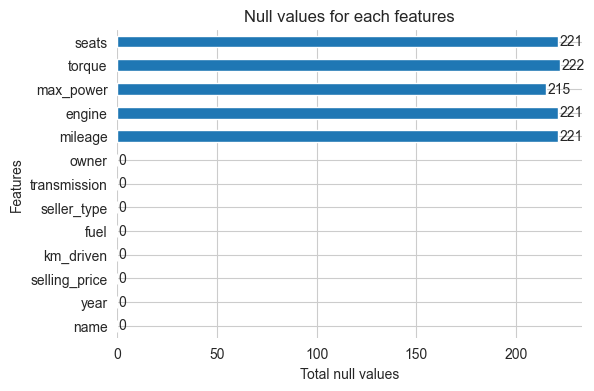

In [50]:
plt.figure(figsize=(6,4))
bar = raw_data.isnull().sum().plot(kind="barh")
for spine in bar.spines.values():
    spine.set_visible(False)
for container in bar.containers:
    bar.bar_label(container, padding=1)

plt.title("Null values for each features")
plt.ylabel("Features")
plt.xlabel("Total null values")
plt.show()

Most basic car attributes like `name`, `year`, `selling_price`, and `fuel` have zero missing entries.
Only technical specification features—`torque` (222), `seats` (221), `engine` (221), `mileage` (221), and `max_power` (215)—contain missing values that need cleaning.

#### Are there any duplicates values?

In [51]:
dup = raw_data.duplicated().sum()
print(f"Total duplicates: {dup} out of {raw_data.shape[0]} data")

Total duplicates: 1202 out of 8128 data


#### What is the distribution of selling_price, and how does it change after applying a log transformation?

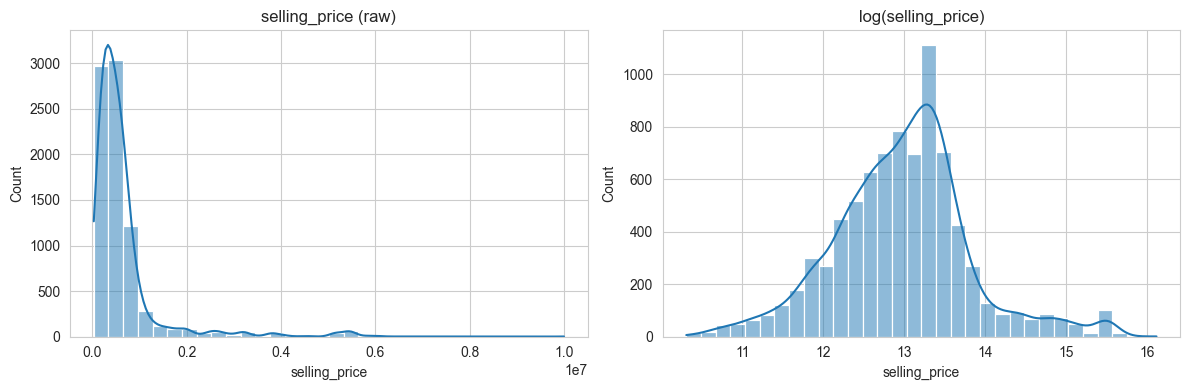

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw_data["selling_price"], bins=32, ax=axes[0], kde=True)
axes[0].set_title("selling_price (raw)")
sns.histplot(np.log(raw_data["selling_price"]), bins=32, ax=axes[1], kde=True)
axes[1].set_title("log(selling_price)")
plt.tight_layout()
plt.show()

The raw `selling_price` distribution is heavily right-skewed, with most cars concentrated at lower prices and a long tail of high-value outliers.
Applying a log transformation successfully reduces the skewness, resulting in a much closer to normal (bell-shaped) distribution that is far better suited for modeling.

#### What are the distributions of Categorical features?

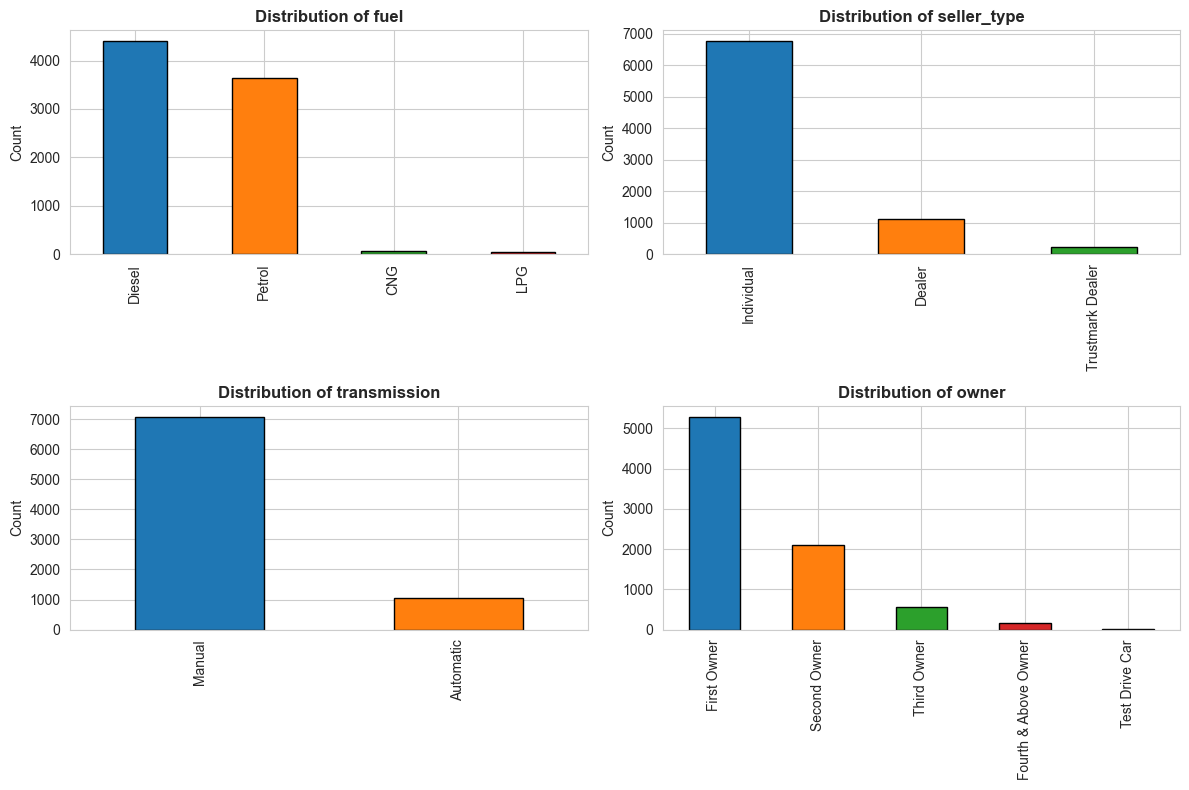

In [53]:
cat_cols = ["fuel", "seller_type", "transmission", "owner"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    counts = raw_data[col].value_counts()

    colors = plt.cm.tab10(range(len(counts)))

    counts.plot(
        kind="bar",
        ax=ax,
        color=colors,
        edgecolor="black"
    )

    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

`Diesel` and `Petrol` heavily dominate fuel types, while CNG and LPG make up a tiny fraction of the dataset.
<br>
The market is overwhelmingly driven by individual sellers rather than commercial or certified dealers.
<br>
`Manual` vehicles and `first-owner` cars comprise the vast majority, showing a steep drop-off for automatics and multi-owner listings.

#### What are the different types of cars in the dataset?

In [54]:
len(raw_data['name'].str.lower().unique())

2038

#### What is the distribution of year?

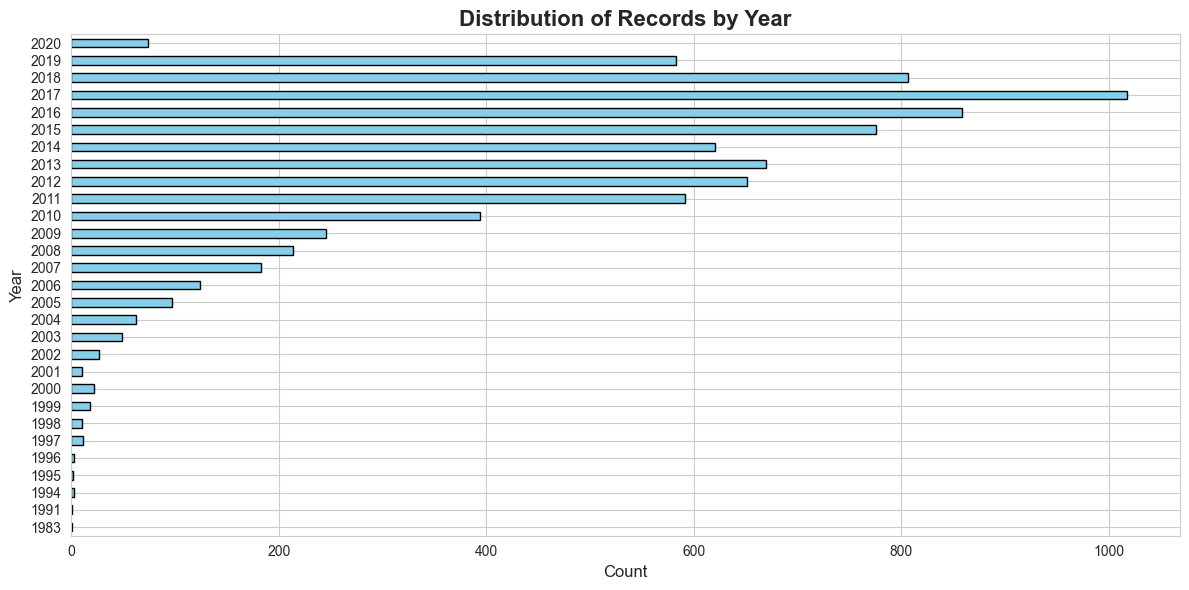

In [55]:
plt.figure(figsize=(12,6))
raw_data['year'].value_counts().sort_index().plot(
    kind="barh",
    color="skyblue",
    edgecolor="black"
)
plt.title("Distribution of Records by Year", fontsize=16, fontweight="bold")
plt.xlabel("Count", fontsize=12)
plt.ylabel("Year", fontsize=12)

plt.tight_layout()
plt.show()

The dataset is heavily concentrated in newer car models, steadily rising over time and peaking in 2017.Listings drop off drastically for vehicles made before 2010, with almost negligible counts for cars from the 1980s and 1990s.

#### What does the distribution of km_driven look like, and are there any notable outliers?

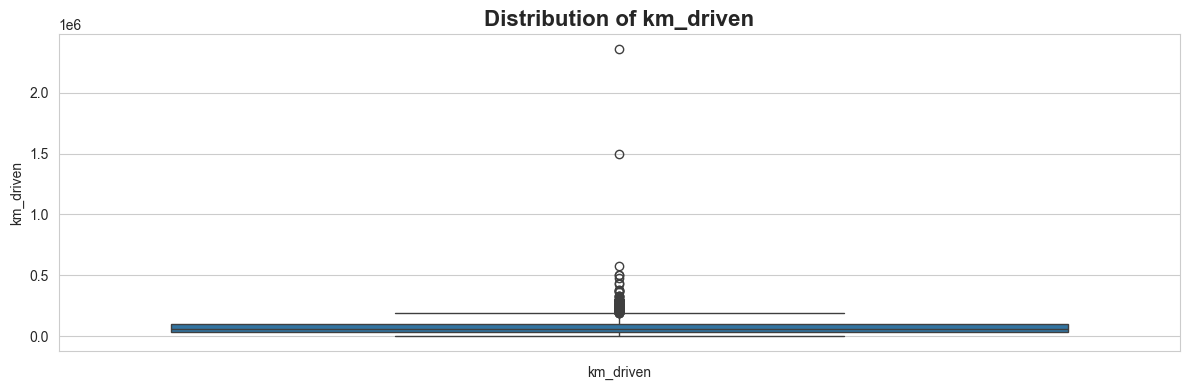

In [56]:
plt.figure(figsize=(12,4))
sns.boxplot(raw_data['km_driven'])
plt.title("Distribution of km_driven", fontsize=16, fontweight="bold")
plt.xlabel("km_driven")
plt.tight_layout()
plt.show()

Most cars have relatively low mileage, with the majority concentrated well below almost 60,000  kilometers. The distribution features extreme high-value outliers, reaching up to over 2 million kilometers driven.

#### What is the distribution of seats?

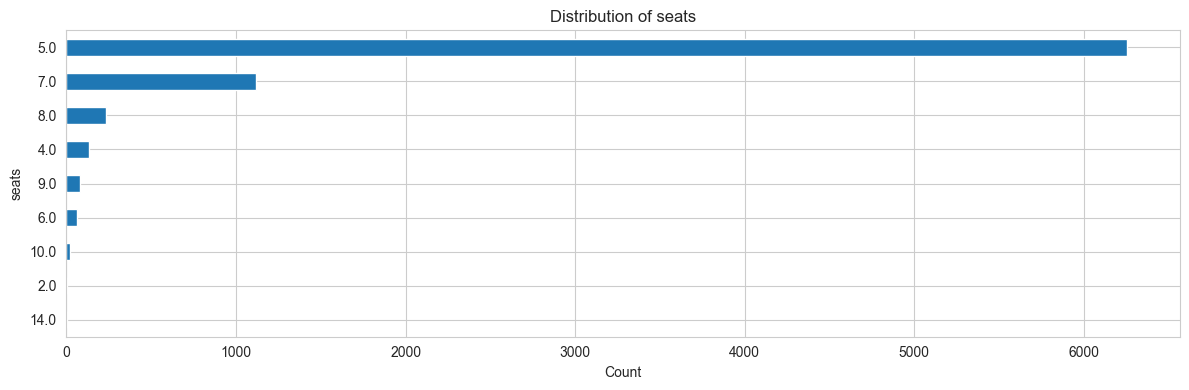

In [57]:
plt.figure(figsize=(12,4))
raw_data.groupby("seats")["seats"].count().sort_values(ascending=True).plot(kind="barh")
plt.title("Distribution of seats")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

The dataset is heavily dominated by standard 5-seater passenger cars, with 7-seaters forming the second most common category. Other seating configurations (such as 4, 6, 8, or rare 14-seaters) represent only a tiny fraction of the total listings.

#### How does selling_price vary with year, and what overall trend can be observed?

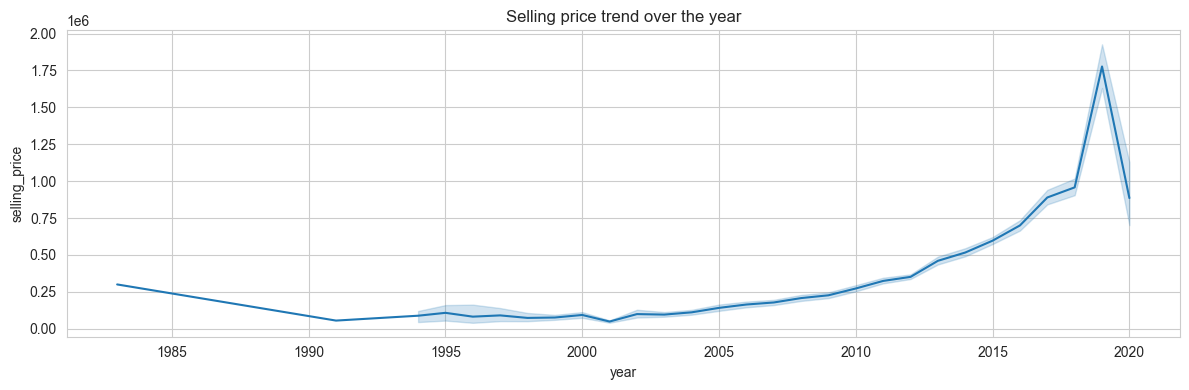

In [58]:
plt.figure(figsize=(12,4))
sns.lineplot(x="year", y="selling_price",data=raw_data)
plt.title("Selling price trend over the year")
plt.tight_layout()
plt.show()

Average selling prices remain low and flat for older vehicles before experiencing steep exponential growth from around 2010 onward. The trend peaks sharply in 2019 near 1.75 million, followed by a sudden drop in 2020  driven by lower sample volume as shown in plot "What is the distribution of year?" or market condition.

#### How does selling_price vary with km_driven, and what overall trend can be observed?

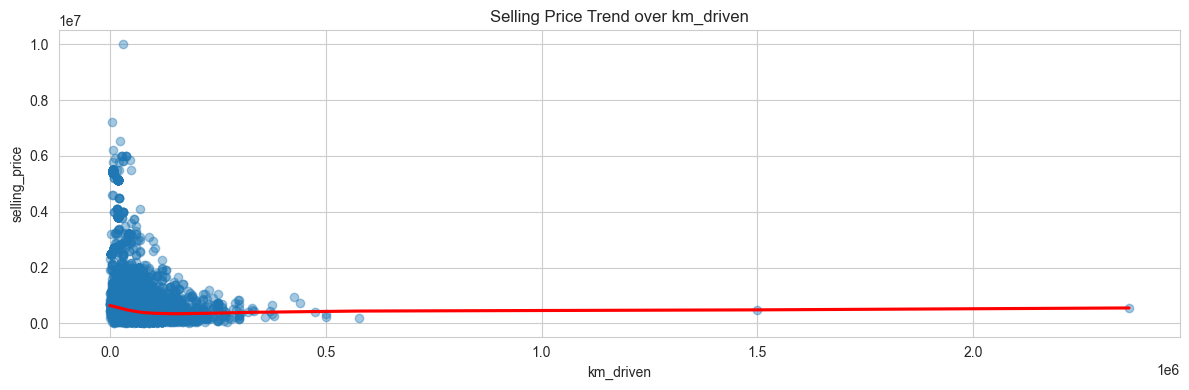

In [59]:
# plt.figure(figsize=(12,4))
# sns.scatterplot(x="km_driven", y="selling_price",data=raw_data)
# plt.title("Selling price trend over km_driven")
# plt.tight_layout()
# plt.show()
plt.figure(figsize=(12, 4))
sns.regplot(
    x="km_driven",
    y="selling_price",
    data=raw_data,
    lowess=True,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Selling Price Trend over km_driven")
plt.tight_layout()
plt.show()

Selling prices drop sharply at low mileage, with high-value vehicles concentrated almost entirely below 60,000 kilometers driven. Beyond this threshold, the trendline completely flattens out, indicating that additional mileage past a certain point has minimal impact on further reducing resale value.

#### How does selling_price vary across fuel, transmission, seller_type, and owner categories?

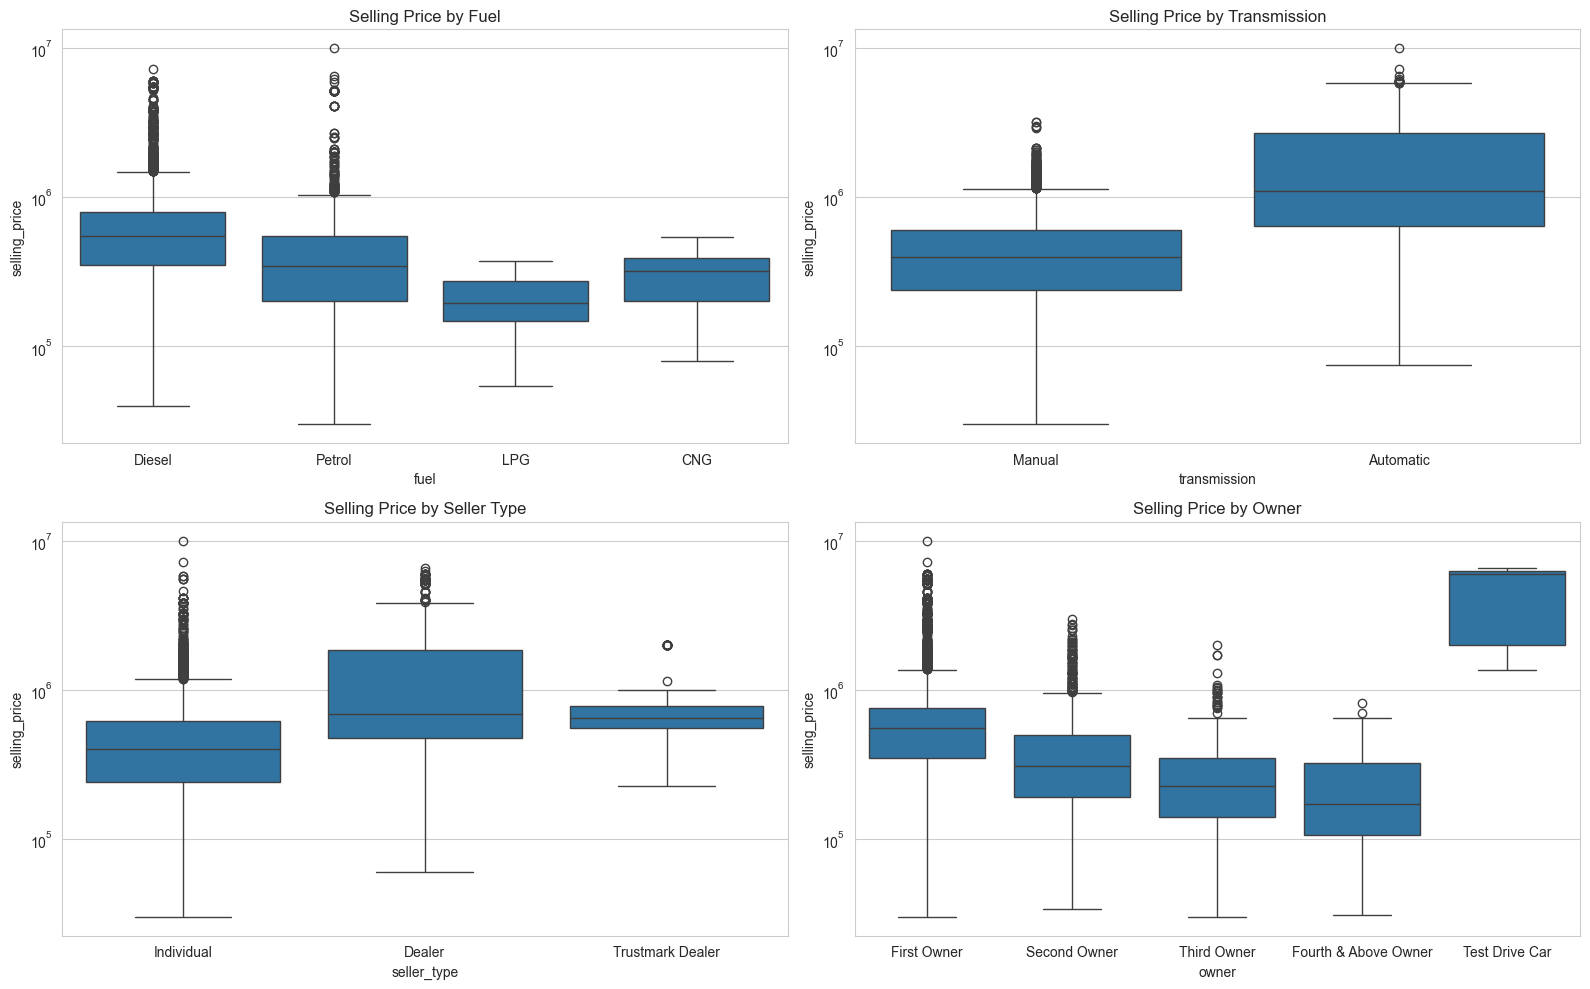

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=raw_data, x="fuel", y="selling_price", ax=axes[0, 0])
axes[0, 0].set_title("Selling Price by Fuel")

sns.boxplot(data=raw_data, x="transmission", y="selling_price", ax=axes[0, 1])
axes[0, 1].set_title("Selling Price by Transmission")

sns.boxplot(data=raw_data, x="seller_type", y="selling_price", ax=axes[1, 0])
axes[1, 0].set_title("Selling Price by Seller Type")

sns.boxplot(data=raw_data, x="owner", y="selling_price", ax=axes[1, 1])
axes[1, 1].set_title("Selling Price by Owner")

# Log scale for selling price
for ax in axes.flat:
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

1.Selling Price by Fuel
Diesel vehicles command the highest median price followed by Petrol, with both containing high luxury outliers. CNG and LPG cars cluster tightly at the lower end of the price spectrum with minimal variance.

2.Selling Price by Transmission
Automatic vehicles show a significantly higher median price and wider range than Manual vehicles. Manual cars dominate the lower-to-mid budget spectrum, though a few high-value outliers exist.

3.Selling Price by Seller Type
Dealers list cars at higher median prices than Individual sellers due to higher-value inventory or markups. Trustmark Dealers display a narrow, controlled price range, while Individual listings span the widest overall price range.

4.Selling Price by Owner
Median selling prices drop consistently with every additional owner tier from First to Fourth Owner. Test Drive Cars act as extreme high-value outliers with by far the highest overall median price.

#### How are engine and max_power correlated with each other and with selling_price?

/var/folders/s4/dby73rpn15xcynyhj02k1trm0000gn/T/ipykernel_1756/2626555400.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['engine'] = [i if type(i) == float else i[0] for i in temp['engine'].str.split(' ').values]
/var/folders/s4/dby73rpn15xcynyhj02k1trm0000gn/T/ipykernel_1756/2626555400.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['max_power'] = [i if type(i) == float else float(*re.findall(pattern, i)) for i in temp['max_power']]


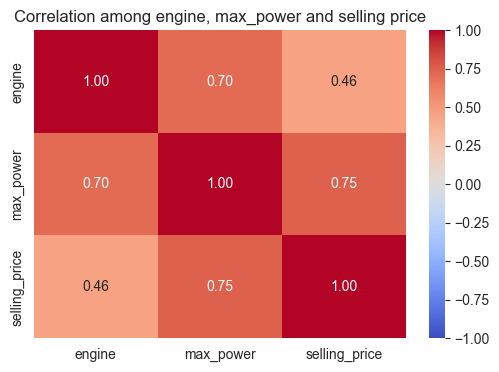

In [61]:
pattern = re.compile(r"\d+(?:\.\d+)?")
temp = raw_data[["engine","max_power","selling_price"]]
temp['engine'] = [i if type(i) == float else i[0] for i in temp['engine'].str.split(' ').values]
temp['max_power'] = [i if type(i) == float else float(*re.findall(pattern, i)) for i in temp['max_power']]

corr_matrix = temp.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation among engine, max_power and selling price')
plt.show()

max_power shows a strong positive correlation with selling_price (0.75), making horsepower a much stronger price driver than engine capacity (0.46).A high correlation of 0.70 between engine and max_power also points to significant multicollinearity between the two performance features.

#### How does mileage relate to selling_price, and what overall trend can be observed?

/var/folders/s4/dby73rpn15xcynyhj02k1trm0000gn/T/ipykernel_1756/2017833203.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp1['mileage'] = [i if type(i) == float else float(*re.findall(pattern, i)) for i in temp1['mileage']]


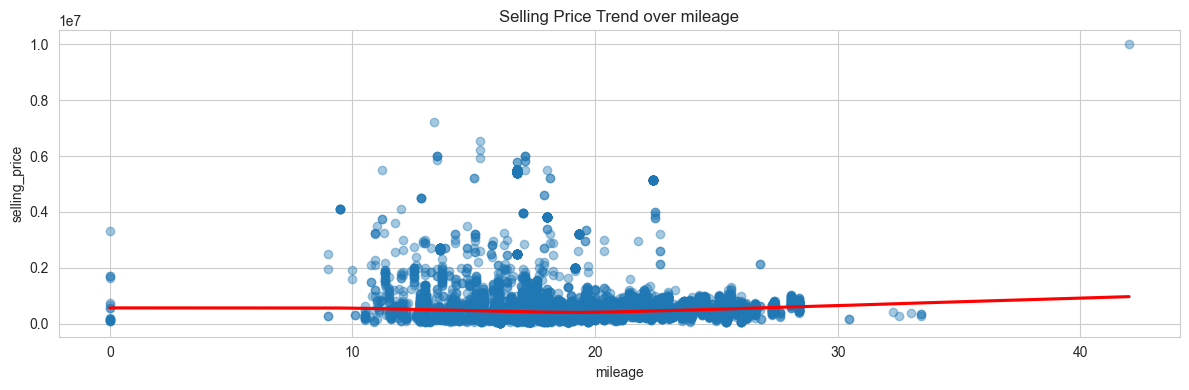

In [62]:
temp1 = raw_data[["selling_price","mileage"]]
temp1['mileage'] = [i if type(i) == float else float(*re.findall(pattern, i)) for i in temp1['mileage']]

plt.figure(figsize=(12, 4))
sns.regplot(
    x="mileage",
    y="selling_price",
    data=temp1,
    lowess=True,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Selling Price Trend over mileage")
plt.tight_layout()
plt.show()

High-priced cars cluster primarily around moderate mileage (10–20 km/l), showing that higher fuel efficiency doesn't necessarily drive up resale value. The overall trendline remains mostly flat across all mileage levels, indicating a very weak linear correlation between fuel economy and selling price. Because of one outlier at the top right , the trend line moved a bit upward.

#### What are the to 10 of brands?

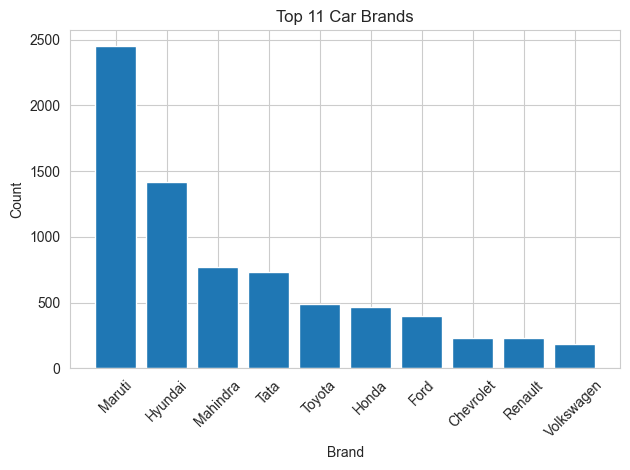

In [63]:
from collections import Counter
brands = [i[0] if len(i) > 1 else np.nan for i in raw_data['name'].str.split(' ')]
c = dict(Counter(brands))
c = sorted(c.items(), key=lambda x:x[1],reverse = True)
to_10 = c[:11]
n,v = [i[0] for i in to_10],[i[1] for i in to_10]

from collections import Counter
brands = [i[0] if len(i) > 1 else np.nan for i in raw_data['name'].str.split(' ')]
c = dict(Counter(brands))
c = sorted(c.items(), key=lambda x:x[1],reverse = True)
to_10 = c[:10]
n,v = [i[0] for i in to_10],[i[1] for i in to_10]

plt.bar(n, v)
plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Count")
plt.title("Top 11 Car Brands")
plt.tight_layout()
plt.show()

# Data pre-processing

Based on our problem statement (Chaky company makes some car but he has diﬀiculty
setting the price for the car):
The target is `selling_price`

In [64]:
X = raw_data.drop(['selling_price'], axis=1).copy()
y = raw_data['selling_price'].copy()

In [65]:
print(X.shape)
print(y.shape)

(8128, 12)
(8128,)


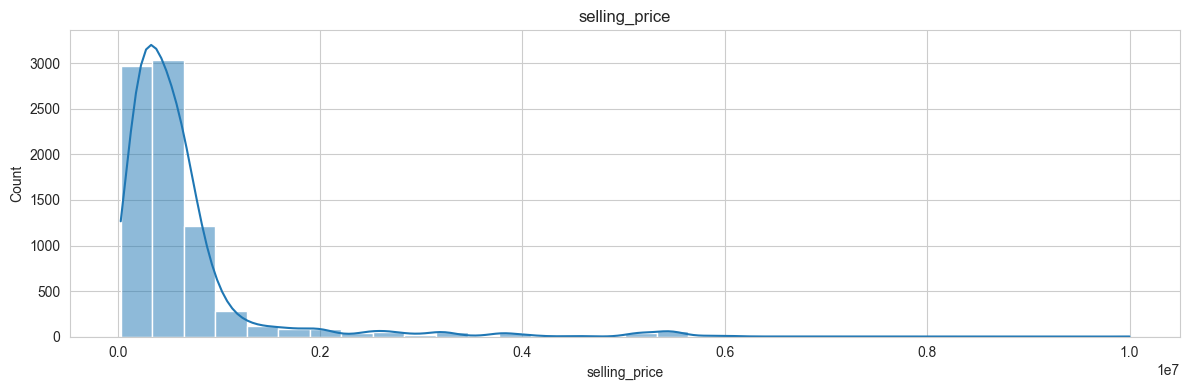

In [66]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))
sns.histplot(y, bins=32, ax=axes, kde=True)
axes.set_title("selling_price")
plt.tight_layout()
plt.show()

In [67]:
cat_cols = [i for i in X.columns if X[i].dtype == np.object_]
num_cols = [i for i in X.columns if X[i].dtype != np.object_]

In [68]:
# striping extra spaces
X[cat_cols] = X[cat_cols].apply(lambda col: col.str.strip())
# removing string from mileage,	engine,	max_power
pattern = re.compile(r"\d+(?:\.\d+)?")
X["mileage"] = [float(re.findall(pattern, i)[0]) if pd.notna(i) else i for i in X['mileage'].values]
X["engine"] = [float(re.findall(pattern, i)[0]) if pd.notna(i) else i for i in X['engine'].values]
X["max_power"] = X['max_power'].str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)

In [69]:
"""For the feature fuel, remove all rows with CNG and
LPG because CNG and LPG use a different
mileage system i.e., km/kg which is different
from kmfeaturepl for Diesel and Petrol"""

mask = (X['fuel'] == 'CNG')  | (X['fuel'] == 'LPG')
index = X[mask].index
assert bool((y.iloc[index].index == X.iloc[index,:].index).all()), "x and y index not same"

X = X.drop(index)
y = y.drop(index)

In [70]:
# taking brand name from name
X.loc[:, "name"] = [i[0] if len(i) > 1 else np.nan for i in X['name'].str.split(' ')]
X.rename(columns={"name":"brand"}, inplace=True)

In [71]:
# Dropping torque column
X = X.drop("torque", axis=1)

In [72]:
# dropping rows related
mask = (X['fuel'] == 'CNG')  | (X['fuel'] == 'LPG')
index = X[mask].index
assert bool((y.iloc[index].index == X.iloc[index,:].index).all()), "x and y index not same"

X = X.drop(index)
y = y.drop(index)

In [73]:
# Dropping Test Drive Car as they have hude value and expensive
index = X[X['owner'] == 'Test Drive Car'].index
print(np.median(y[index]) > np.median(y.drop(index)))
X = X.drop(index)
y = y.drop(index)

True


In [74]:
# changing the data type
X[['mileage', 'engine', 'max_power']] = X[['mileage', 'engine', 'max_power']].astype(float)

In [75]:
num_cols = [i for i in X.columns if X[i].dtype is not np.object_]
cat_cols = [i for i in X.columns if X[i].dtype == np.object_]

In [76]:
# lower the text data to avoid uppercase and lowercase issue of same data
X[cat_cols] = X[cat_cols].apply(lambda x:x.str.lower())

In [77]:
# check null values
X.isnull().sum()

brand             0
year              0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage         214
engine          214
max_power       208
seats           214
dtype: int64

Rows missing all four specifications—mileage, engine, max_power, and seats—were removed because they lack substantive vehicle attributes required for price prediction. Without these core features, the records contribute no meaningful signal to the model and function as structural noise rather than informative observations.

In [78]:
mask_all_null = X[['mileage','engine','max_power','seats']].isna().all(axis=1)
indx = X[mask_all_null].index
X = X.drop(indx)
y = y.drop(indx)

In [79]:
X.isnull().sum()

brand           0
year            0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         6
engine          6
max_power       0
seats           6
dtype: int64

In [80]:
# total duplicates
print(X.duplicated().sum())
index = [*X[X.duplicated()].index]
X = X.drop(index)
y = y.drop(index)

1675


In [81]:
# applying log to dependent variable, as
y_log = np.log(y)

In [82]:
print(X.shape)
print(y.shape)
print(y_log.shape)

(6145, 11)
(6145,)
(6145,)


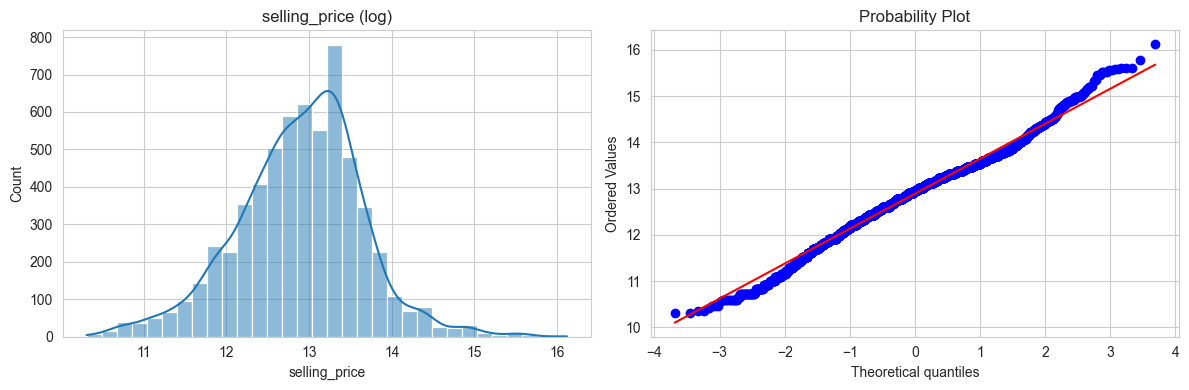

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_log, bins=32, ax=axes[0], kde=True)
axes[0].set_title("selling_price (log)")
stats.probplot(y_log, dist="norm", plot=axes[1])
plt.tight_layout()
plt.show()

While applying the log transformation to `selling_price` successfully compresses the extreme high values and drastically reduces the original heavy right-skew, it cannot fully eliminate the skewness. Residual deviations still persist in the lower and upper tails because standard logarithmic scaling cannot completely smooth out real-world market extremes—such as heavily depreciated budget cars at the low end and rare luxury vehicles at the high end.

In [84]:
print(X.duplicated().sum())
print("-"*10)
print(X.isnull().sum())

0
----------
brand           0
year            0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         3
engine          3
max_power       0
seats           3
dtype: int64


In [85]:
for i in ['mileage','engine']:
    print(f"{i}:")
    print(f"mean=> {np.mean(X[i].dropna())}")
    print(f"median=> {np.median(X[i].dropna())}")

mileage:
mean=> 19.315068381634646
median=> 19.3
engine:
mean=> 1445.779876261804
median=> 1248.0


In [86]:
seat = X['seats'].value_counts()
print(seat.idxmax())
print(max(seat.values))

5.0
4762


## Data split

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, y_log_train, y_log_test = train_test_split(
    X, y, y_log, test_size=0.20, random_state=42
)

In [88]:
print(X_train.shape)
print(y_train.shape)

(4916, 11)
(4916,)


In [89]:
print(X_test.shape)
print(y_test.shape)

(1229, 11)
(1229,)


## Data Processing

In [90]:
for i in cat_cols:
    print(f"{i},Unique: =>{len(X[i].unique())}")

brand,Unique: =>31
fuel,Unique: =>2
seller_type,Unique: =>3
transmission,Unique: =>2
owner,Unique: =>4


In [91]:
for i in cat_cols:
    print(f"{i},Unique: =>{len(X_train[i].unique())}")

brand,Unique: =>30
fuel,Unique: =>2
seller_type,Unique: =>3
transmission,Unique: =>2
owner,Unique: =>4


In [92]:
for i in cat_cols:
    print(f"{i},Unique: =>{len(X_test[i].unique())}")

brand,Unique: =>25
fuel,Unique: =>2
seller_type,Unique: =>3
transmission,Unique: =>2
owner,Unique: =>4


In [93]:
counts = X['brand'].value_counts()
print(counts.tail(10))          # the rarest brands
print((counts < 5).sum(), "brands have fewer than 5 rows")
print((counts == 1).sum(), "brands have exactly 1 row")

brand
force         4
isuzu         4
ambassador    4
daewoo        3
land          3
mg            3
kia           3
lexus         1
ashok         1
opel          1
Name: count, dtype: int64
10 brands have fewer than 5 rows
3 brands have exactly 1 row


# Baseline model

Brand has 32 categories with several rare classes (as few as 1 sample). One-hot would create sparse, unstable features; smoothed target encoding captures each brand's price level while shrinking rare-category estimates toward the global mean, preventing overfitting on low-count brands.

In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

num_impute_pipeline = Pipeline(steps=[
    ("median_imput", SimpleImputer(strategy='median'))
])
cat_impute_pipeline = Pipeline(steps=[
    ("cat_imput", SimpleImputer(strategy='most_frequent'))
])

ct = ColumnTransformer(
    transformers=[
        ("num", num_impute_pipeline, ['mileage','engine']),
        ("cat", cat_impute_pipeline, ["seats"]),
        ("OHE", OneHotEncoder(handle_unknown="ignore"), ["fuel", "seller_type", "transmission", "owner"]),
        ("target_enc", TargetEncoder(target_type="continuous", smooth="auto",random_state=42), ["brand"]),
    ],
    remainder="drop"
)

# baseline pipeline 1
baseline = Pipeline([
    ("processing", ct),
    ("model", DummyRegressor(strategy="mean")),
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

In [95]:
print("Baseline model no log:")
print_regression_metrics(y_test, baseline_pred)

Baseline model no log:
SST  : 360366499418101.7500
SSE  : 360606922289999.4375
MSE  : 293414908291.2933
RMSE : 541677.8639
R²   : -0.0007


In [96]:
# baseline pipeline 2
baseline2 = Pipeline([
    ("processing", ct),
    ("model", DummyRegressor(strategy="mean")),
])

baseline2.fit(X_train, y_log_train)
baseline_pred2 = baseline2.predict(X_test)

In [97]:
print("Baseline model with log:")
print_regression_metrics(y_log_test, baseline_pred2)

Baseline model with log:
SST  : 710.3106
SSE  : 710.8095
MSE  : 0.5784
RMSE : 0.7605
R²   : -0.0007


Both baselines yield R² ≈ 0, confirming the mean is the optimal constant predictor. The raw-scale SST (≈369T) reveals extreme right-skew in *y*, while the log-scale SST (≈710) compresses variance for stable modeling. These floors benchmark all subsequent models: any real model using *X* must outperform these RMSE values.

# Feature selection

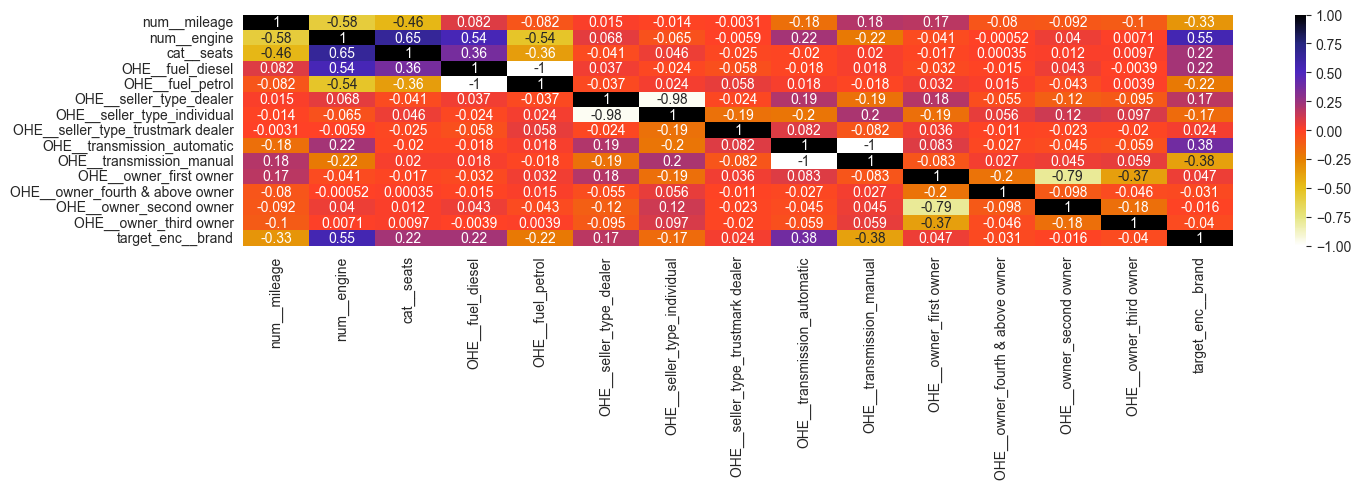

In [98]:
X_trans = ct.fit_transform(X_train,y_log_train)
feature_names = ct.get_feature_names_out()
X_proc = pd.DataFrame(X_trans, columns=feature_names, index=X_train.index)

corr = X_proc.corr()
plt.figure(figsize=(15,5))
sns.heatmap(corr, annot=True, cmap=plt.cm.CMRmap_r)
plt.tight_layout()
plt.show()

In [99]:
# correlation selection with 50% probability
pcs = calculate_correlation(X_proc, 0.50)

Highly correlated columns:
num__mileage
num__engine
cat__seats
OHE__fuel_diesel
OHE__fuel_petrol
OHE__seller_type_dealer
OHE__seller_type_individual
OHE__transmission_automatic
OHE__transmission_manual
OHE__owner_first owner
OHE__owner_second owner
target_enc__brand


Feature Selection Using Information Gain

In [100]:
from sklearn.feature_selection import mutual_info_regression,SelectKBest,SelectPercentile

train_pipeline = Pipeline(steps=[
    ("transform", ct),
    ("select", SelectKBest(score_func=mutual_info_regression, k=10))
])
fs = train_pipeline.fit_transform(X_train, y_log_train)

In [101]:
mask = train_pipeline.named_steps["select"].get_support()
feature_names = train_pipeline.named_steps["transform"].get_feature_names_out()

selected_features = feature_names[mask]
print(selected_features)

scores = train_pipeline.named_steps["select"].scores_
feature_scores = pd.Series(scores, index=feature_names).sort_values(ascending=False)

['num__mileage' 'num__engine' 'cat__seats' 'OHE__fuel_diesel'
 'OHE__fuel_petrol' 'OHE__seller_type_dealer'
 'OHE__transmission_automatic' 'OHE__transmission_manual'
 'OHE__owner_first owner' 'target_enc__brand']


In [102]:
pd.DataFrame(feature_scores)

,0
num__mileage,0.481191
num__engine,0.468827
target_enc__brand,0.220557
cat__seats,0.084378
OHE__transmission_automatic,0.079797
OHE__transmission_manual,0.076354
OHE__fuel_diesel,0.074878
OHE__fuel_petrol,0.072542
OHE__owner_first owner,0.065807
OHE__seller_type_dealer,0.056717


In [103]:
# features commom in pearson correlation and mutual_info_regression
pcsf = [X_proc.columns[i] for i in pcs]
commonFeas = [i for i in selected_features if i in pcsf]
print("Common features selected by both")
print(commonFeas)

Common features selected by both
['num__mileage', 'num__engine', 'cat__seats', 'OHE__fuel_diesel', 'OHE__fuel_petrol', 'OHE__seller_type_dealer', 'OHE__transmission_automatic', 'OHE__transmission_manual', 'OHE__owner_first owner', 'target_enc__brand']


In [104]:
# uncommom features from both
print("mutual_info_regression's features not found in pearson correlation")
for i in selected_features:
    if i not in pcsf:
        print(i)

print("-"*50)
print("pearson correlation's features not found in mutual_info_regression")
for j in pcsf:
    if j not in selected_features:
        print(j)

mutual_info_regression's features not found in pearson correlation
--------------------------------------------------
pearson correlation's features not found in mutual_info_regression
OHE__seller_type_individual
OHE__owner_second owner


In [105]:
selected_features = selected_features

# Train & compare multiple models
models:
1. Multiple Linear Regression
2. XGBRegressor
3. Random Forest Regression
4. Ridge

In [106]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,cross_validate,KFold
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# CV

In [107]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge":Ridge(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

In [108]:
from functools import partial

def perform_cv(models, X_train, y_train=None, y_log_train=None, cv_=5, selected_features=None, k=10):
    def sse(y_true, y_pred):
        return np.sum((y_true - y_pred) ** 2)

    scoring = {
        "SSE": make_scorer(sse, greater_is_better=False),
        "MSE": "neg_mean_squared_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    }
    cv_results = {}
    cv_results2 = {}

    CV = KFold(n_splits=cv_, shuffle=True, random_state=42)

    # fixed seed so SelectKBest gives identical results every run
    mi_fixed = partial(mutual_info_regression, random_state=42)

    if y_train is not None:
        for name, m in models.items():
            if selected_features:
                pipe = Pipeline(steps=[
                    ("transform", ct),
                    ("select", SelectKBest(score_func=mi_fixed, k=k)),
                    ("model", m)
                ])
            else:
                pipe = Pipeline(steps=[
                    ("transform", ct),
                    ("model", m)
                ])
            results1 = cross_validate(pipe, X_train, y_train, cv=CV, scoring=scoring)

            cv_results[name] = {
                "SSE": -results1["test_SSE"],
                "MSE": -results1["test_MSE"],
                "RMSE": -results1["test_RMSE"],
                "R2": results1["test_R2"],
            }

    if y_log_train is not None:
        for name1, m1 in models.items():
            if selected_features:
                pipe1 = Pipeline(steps=[
                    ("transform", ct),
                    ("select", SelectKBest(score_func=mi_fixed, k=k)),
                    ("model", m1)
                ])
            else:
                pipe1 = Pipeline(steps=[
                    ("transform", ct),
                    ("model", m1)
                ])
            results2 = cross_validate(pipe1, X_train, y_log_train, cv=CV, scoring=scoring)

            cv_results2[name1] = {
                "SSE": -results2["test_SSE"],
                "MSE": -results2["test_MSE"],
                "RMSE": -results2["test_RMSE"],
                "R2": results2["test_R2"],
            }

    fr = {
        'normal_y': cv_results,
        'logY': cv_results2,
        'cv': CV,
    }
    return fr

### Without feature selection

In [109]:
res = perform_cv(
    models=models,
    X_train=X_train,
    y_train=y_train,
    y_log_train=y_log_train,
    cv_=10,
    selected_features=None
)

In [110]:
df_normal = createDF(res['normal_y'], "normal_y")
df_log = createDF(res['logY'], "logY")
combined_df1 = pd.concat([df_normal, df_log])
combined_df1

SSE                        RMSE  \
Experiment Model                                                                
normal_y   Random Forest      3.17e+13 ± 1.31e+13  248,344.5574 ± 52,957.1412   
           XGBRegressor       3.21e+13 ± 1.18e+13  250,972.2469 ± 47,875.6364   
           Ridge              6.13e+13 ± 1.93e+13  349,186.8584 ± 52,867.2020   
           Linear Regression  6.13e+13 ± 1.93e+13  349,191.8571 ± 52,859.2987   
logY       XGBRegressor       4.63e+01 ± 4.07e+00             0.3067 ± 0.0136   
           Random Forest      5.05e+01 ± 5.92e+00             0.3200 ± 0.0191   
           Ridge              1.21e+02 ± 5.86e+00             0.4962 ± 0.0120   
           Linear Regression  1.21e+02 ± 5.85e+00             0.4962 ± 0.0120   

                                           R2  
Experiment Model                               
normal_y   Random Forest      0.7520 ± 0.0997  
           XGBRegressor       0.7440 ± 0.1035  
           Ridge              0.5305 ± 0.0375  
           Linear Regression  0.5304 ± 0.0375  
logY       XGBRegressor       0.8354 ± 0.0226  
           Random Forest      0.8207 ± 0.0270  
           Ridge              0.5717 ± 0.0253  
           Linear Regression  0.5717 ± 0.0253

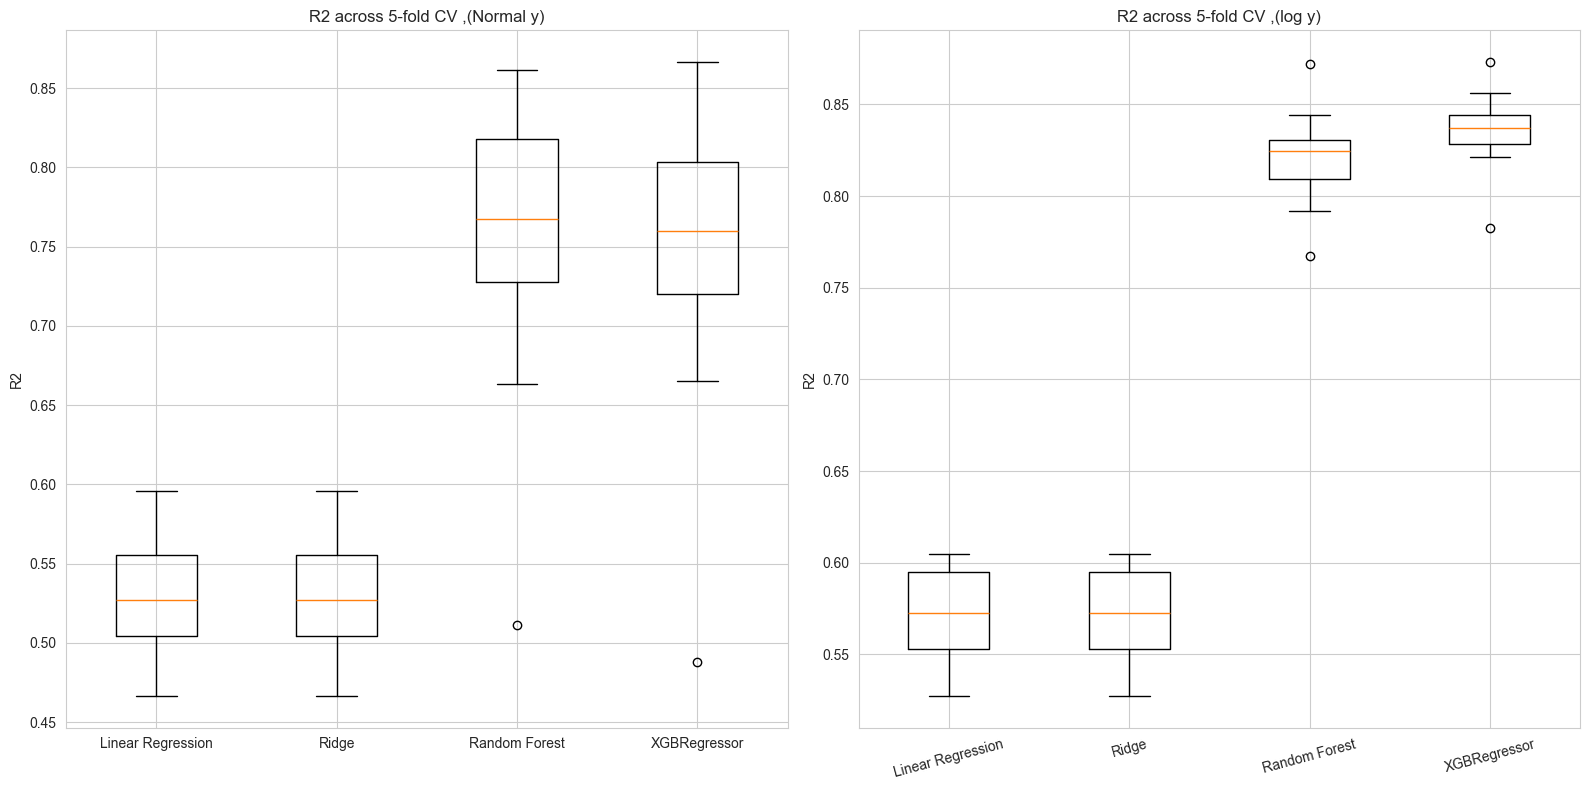

In [111]:
plot_cv_res(res['normal_y'], res['logY'])

### With feature selection

In [112]:
resFS = perform_cv(
    models=models,
    X_train=X_train,
    y_train=y_train,
    y_log_train=y_log_train,
    cv_=10,
    selected_features=True,
    k=11 # top 11 features to select
)

In [113]:
df_normal = createDF(resFS['normal_y'], "normal_y")
df_log = createDF(resFS['logY'], "logY")
combined_df2 = pd.concat([df_normal, df_log])
combined_df2

SSE                        RMSE  \
Experiment Model                                                                
normal_y   Random Forest      3.20e+13 ± 1.34e+13  249,237.3876 ± 53,604.0724   
           XGBRegressor       3.31e+13 ± 1.23e+13  254,966.0484 ± 48,533.7564   
           Ridge              6.14e+13 ± 1.92e+13  349,308.9855 ± 52,652.1667   
           Linear Regression  6.14e+13 ± 1.92e+13  349,313.4720 ± 52,636.4001   
logY       XGBRegressor       4.59e+01 ± 4.53e+00             0.3050 ± 0.0154   
           Random Forest      5.00e+01 ± 5.45e+00             0.3184 ± 0.0178   
           Ridge              1.23e+02 ± 6.78e+00             0.4995 ± 0.0138   
           Linear Regression  1.23e+02 ± 6.77e+00             0.4995 ± 0.0138   

                                           R2  
Experiment Model                               
normal_y   Random Forest      0.7502 ± 0.1004  
           XGBRegressor       0.7371 ± 0.1052  
           Ridge              0.5300 ± 0.0380  
           Linear Regression  0.5300 ± 0.0381  
logY       XGBRegressor       0.8371 ± 0.0226  
           Random Forest      0.8226 ± 0.0248  
           Ridge              0.5658 ± 0.0265  
           Linear Regression  0.5658 ± 0.0265

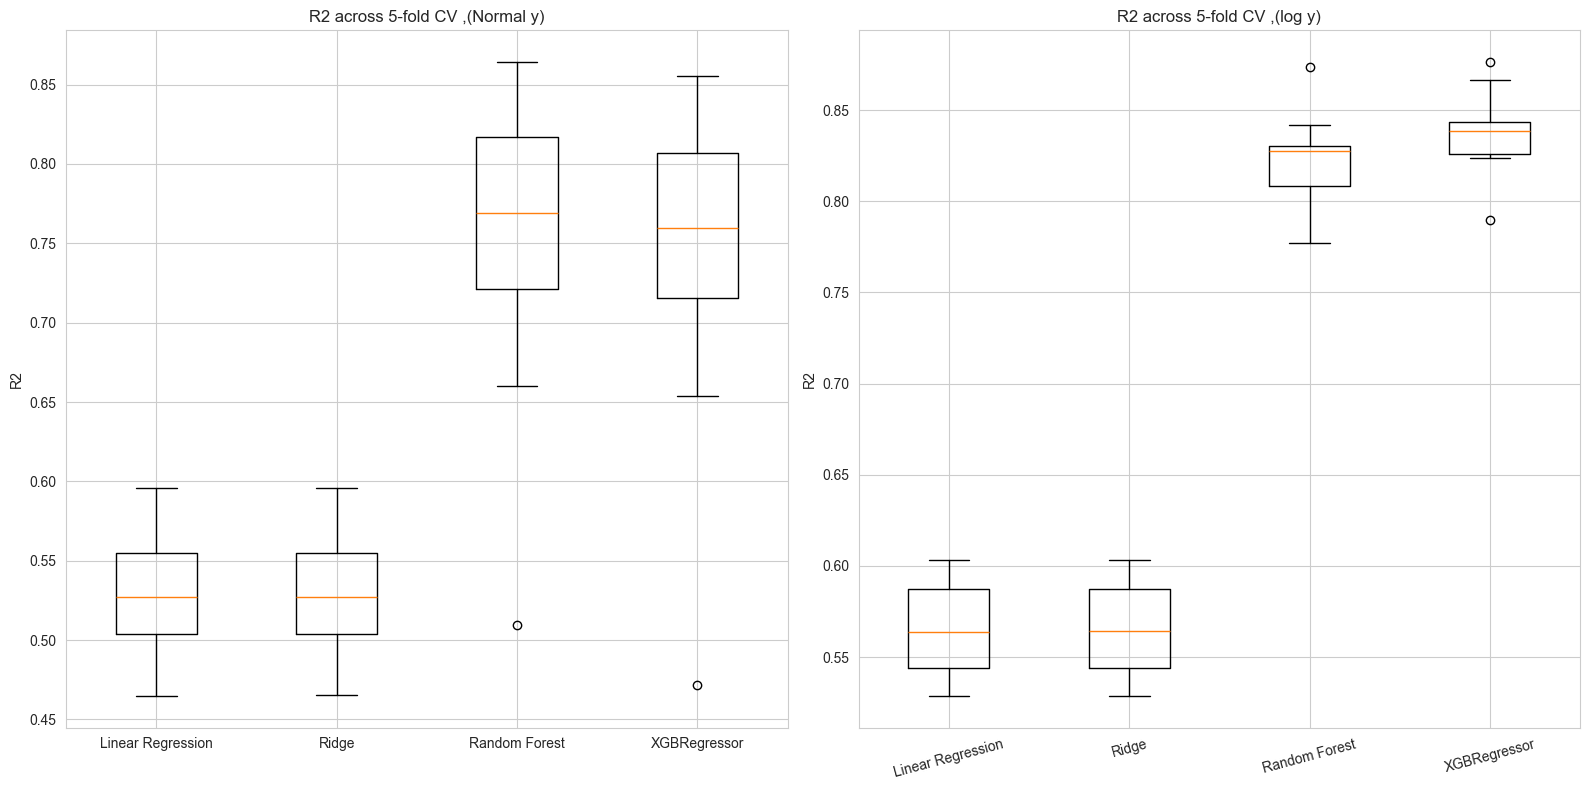

In [114]:
plot_cv_res(resFS['normal_y'], resFS['logY'])

All the models we tested did much better than the baseline (DummyRegressor), which basically had no predictive power (R² close to zero) on both the normal and log-transformed price scales. This confirms our features actually contain useful information for predicting price.

On the original price scale, tree-based models — XGBoost and Random Forest — performed best. XGBoost got an R² of 0.7440  and an RMSE of about 254,966, which is way better than the baseline's RMSE of 541677.8639. Linear Regression and Ridge Regression performed almost the same as each other, both landing around R² = 0.5304 to 0.5305. This tells us the relationship between features and price isn't linear, and adding L2 regularization (Ridge) didn't really help.

When we log-transformed the target (price), every model improved noticeably. XGBoost hit an R² of 0.8354 without feature selection, and 0.8371  with it — suggesting that price behaves more like a multiplicative process than an additive one, percentage changes matter more than fixed dollar changes.

Feature selection helped the tree-based models a little, but actually hurt the linear models slightly. This suggests linear models do better when they can use all the weaker signals together, rather than having some removed.

Based on all this, we'll move forward with XGBoost and Random Forest trained on log-transformed prices — ideally with feature selection — and fine-tune them further using GridSearchCV in the next phase.

# Hyperparameter tuning on good performing models

Used  features selection to fine tune models

Selected Models for fine tuning:

1. XGBRegressor
2. Random Forest Regression

In [115]:
tuning_grids = {
    "Random Forest": (RandomForestRegressor(random_state=42, n_jobs=2), {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5, 1.0],
    }),
    "XGBRegressor": (XGBRegressor(random_state=42, n_jobs=2, objective="reg:squarederror"), {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [3, 4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    }),
}

In [116]:
# fixed seed so SelectKBest gives identical results every run
mi_fixed = partial(mutual_info_regression, random_state=42)
k = 11
cv = resFS["cv"] # used the cv/KFold from earlier cross validation exp to keep consistency, used

rf_pipeline = Pipeline(steps=[
    ('transformer', ct),
    ("select", SelectKBest(score_func=mi_fixed, k=k)),
    ("model", tuning_grids["Random Forest"][0])
])

xgb_pipeline = Pipeline(steps=[
    ('transformer', ct),
    ("select", SelectKBest(score_func=mi_fixed, k=k)),
    ("model", tuning_grids["XGBRegressor"][0])
])

In [117]:
from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    rf_pipeline, tuning_grids["Random Forest"][1],
    n_iter=30, cv=cv, scoring="r2", random_state=42, n_jobs=2
)

xgb_search = RandomizedSearchCV(
    xgb_pipeline, tuning_grids["XGBRegressor"][1],
    n_iter=30, cv=cv, scoring="r2", random_state=42, n_jobs=2
)

In [118]:
# fit RandomizedSearchCV on random forest
rf_search.fit(X_train, y_log_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 0.5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [200, 400, ...]}"
,n_iter,30
,scoring,'r2'
,n_jobs,2
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [119]:
print(rf_search.best_score_)
print(rf_search.best_params_)

0.8266353278896925
{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}


In [120]:
# fit RandomizedSearchCV on XGBRegressor
xgb_search.fit(X_train, y_log_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.85, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [200, 400, ...], ...}"
,n_iter,30
,scoring,'r2'
,n_jobs,2
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [121]:
print(xgb_search.best_score_)
print(xgb_search.best_params_)

0.8389163990717925
{'model__subsample': 0.85, 'model__n_estimators': 600, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}


## Test the fine-tuned model on test set

In [122]:
y_true_price = np.exp(y_log_test)

In [123]:
best_rf = rf_search.best_estimator_
rfr_y_pred = np.exp(best_rf.predict(X_test))

mse_rf = MSE(y_true_price, rfr_y_pred)
rmse_rf = RMSE(y_true_price, rfr_y_pred)
r2_rf = R2(y_true_price, rfr_y_pred)

In [124]:
best_xgb = xgb_search.best_estimator_
xgb_y_pred = np.exp(best_xgb.predict(X_test))

mse_xgb = MSE(y_true_price, xgb_y_pred)
rmse_xgb = RMSE(y_true_price, xgb_y_pred)
r2_xgb = R2(y_true_price, xgb_y_pred)

# Final evaluation

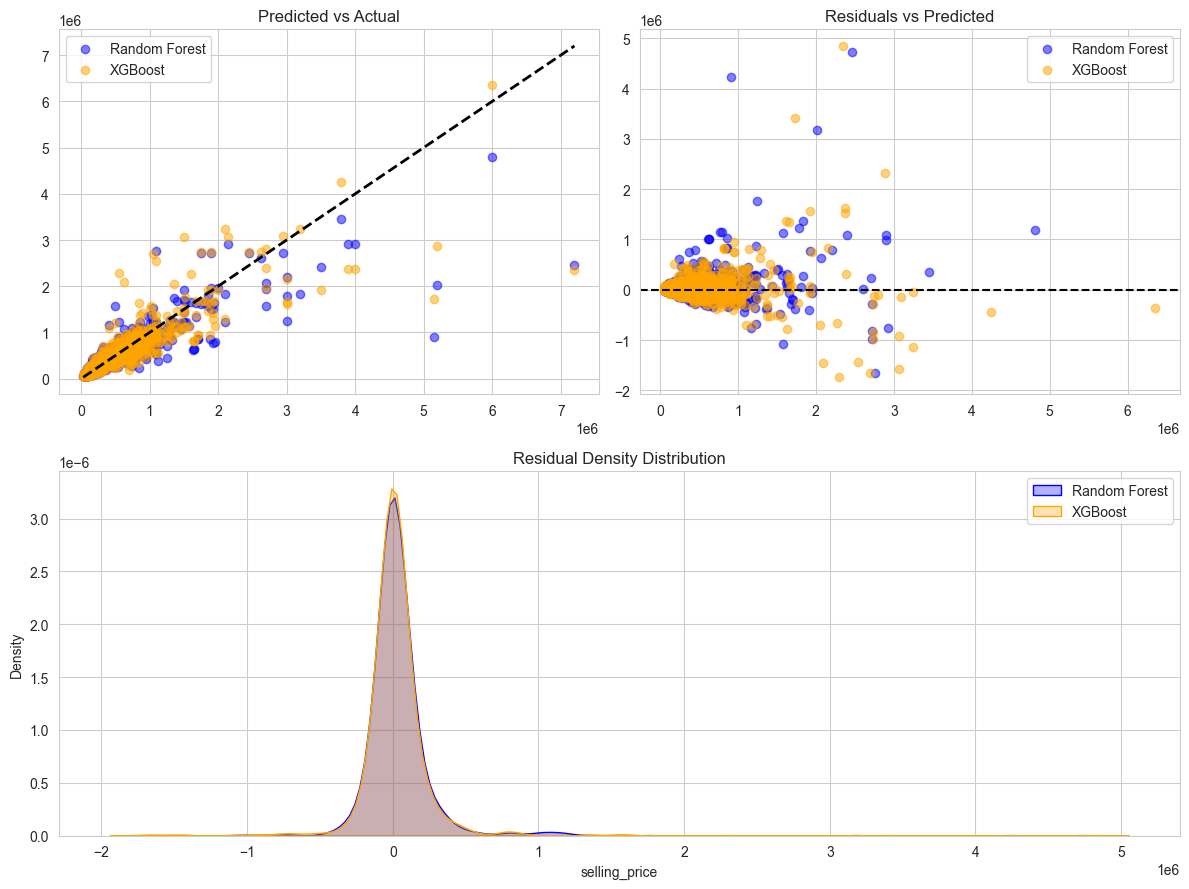

In [125]:
rf_preds = rfr_y_pred
xgb_preds = xgb_y_pred
rf_resids = y_test - rf_preds
xgb_resids = y_test - xgb_preds

fig, axes = plt.subplot_mosaic([['pred_vs_act', 'res_vs_pred'],
                                ['res_dist',    'res_dist']],
                               figsize=(12, 9))

# Predicted vs Actual
axes['pred_vs_act'].scatter(y_test, rf_preds, alpha=0.5, label='Random Forest', color='blue')
axes['pred_vs_act'].scatter(y_test, xgb_preds, alpha=0.5, label='XGBoost', color='orange')
axes['pred_vs_act'].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes['pred_vs_act'].set_title('Predicted vs Actual')
axes['pred_vs_act'].legend()

# Residuals vs Predicted
axes['res_vs_pred'].scatter(rf_preds, rf_resids, alpha=0.5, label='Random Forest', color='blue')
axes['res_vs_pred'].scatter(xgb_preds, xgb_resids, alpha=0.5, label='XGBoost', color='orange')
axes['res_vs_pred'].axhline(0, color='black', linestyle='--')
axes['res_vs_pred'].set_title('Residuals vs Predicted')
axes['res_vs_pred'].legend()

# Residual Distribution (Full Width Row 2)
sns.kdeplot(rf_resids, ax=axes['res_dist'], label='Random Forest', color='blue', fill=True, alpha=0.3)
sns.kdeplot(xgb_resids, ax=axes['res_dist'], label='XGBoost', color='orange', fill=True, alpha=0.3)
axes['res_dist'].set_title('Residual Density Distribution')
axes['res_dist'].legend()

plt.tight_layout()
plt.show()

 The plots compare Random Forest and XGBoost performance. The predicted vs actual plot shows both models follow the ideal line but struggle with high-value predictions. The residuals vs predicted plot reveals errors increase for higher-priced items, indicating heteroscedasticity. The density plot shows residuals cluster near zero, meaning both models are generally accurate, though XGBoost shows slightly more extreme positive errors. Overall, neither model perfectly captures outliers, but both perform reasonably on average.

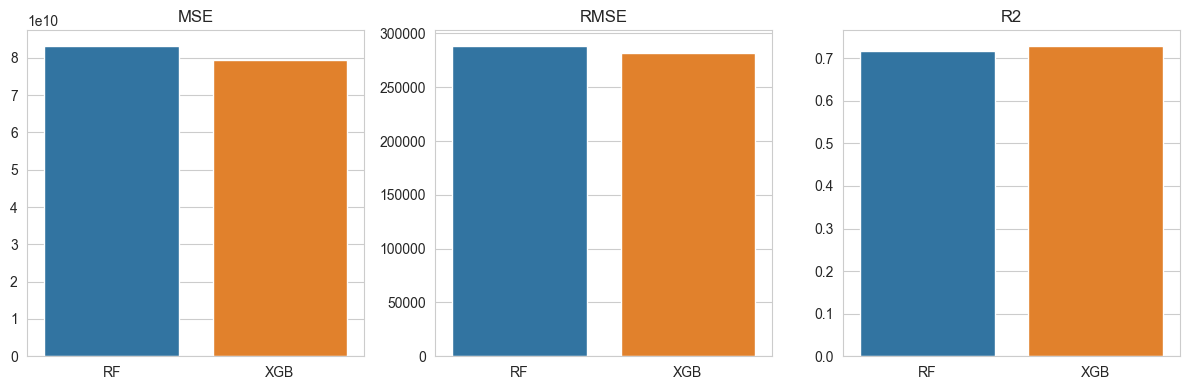

In [126]:
fig, axis = plt.subplots(1,3, figsize=(12,4))

models_mse = {"RF":mse_rf, "XGB":mse_xgb}
sns.barplot(x=models_mse.keys(), y=models_mse.values(), ax=axis[0], hue=models_mse.keys())
axis[0].set_title("MSE")

models_rmse = {"RF":rmse_rf, "XGB":rmse_xgb}
sns.barplot(x=models_rmse.keys(), y=models_rmse.values(), ax=axis[1], hue=models_rmse.keys())
axis[1].set_title("RMSE")

models_r2 = {"RF":r2_rf, "XGB":r2_xgb}
sns.barplot(x=models_r2.keys(), y=models_r2.values(), ax=axis[2], hue=models_r2.keys())
axis[2].set_title("R2")

plt.tight_layout()
plt.show()

 XGBoost slightly outperforms Random Forest across all metrics. It has lower MSE and RMSE, meaning its predictions are closer to actual values on average. XGBoost also shows a higher R² score, explaining more variance in the data. However, the difference between both models is modest—neither dramatically outperforms the other. Overall, XGBoost is marginally more accurate, but both models achieve reasonable predictive performance.

## Saving the best model

In [127]:
import joblib, os, json

In [128]:
path = os.path.join(os.getcwd(), "saved_models")

In [129]:
joblib.dump(xgb_search.best_estimator_, os.path.join(path, "xgb_best_model.pkl"))

['/Users/imtiaz/Documents/Programming/car_price_predictor/saved_models/xgb_best_model.pkl']

In [140]:
# save pre-processing info
defaults = {}
# Numeric: median imputation
for col in ['year', 'km_driven', 'max_power']:
    defaults[col] = float(X_train[col].median())

# Categorical: mode imputation 
for col in ['fuel', 'seller_type', 'transmission', 'owner', 'brand']:
    defaults[col] = X_train[col].mode()[0]

with open(os.path.join(path, 'imputation_defaults.json'), 'w') as f:
    json.dump(defaults, f)

In [131]:
path = os.path.join(os.getcwd(), "saved_models")
loaded_model = joblib.load(os.path.join(path, "xgb_best_model.pkl"))

In [132]:
loaded_model

,steps,"[('transformer', ...), ('select', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [133]:
# selected features
transformer = loaded_model.named_steps['transformer']
all_cols = transformer.get_feature_names_out()
selector = loaded_model.named_steps['select']

feature_names = selector.get_feature_names_out(all_cols)
print(feature_names)

['num__mileage' 'num__engine' 'cat__seats' 'OHE__fuel_diesel'
 'OHE__fuel_petrol' 'OHE__seller_type_dealer'
 'OHE__seller_type_individual' 'OHE__transmission_automatic'
 'OHE__transmission_manual' 'OHE__owner_first owner' 'target_enc__brand']


In [137]:
sample_data = pd.DataFrame({
    'brand': ['Maruti'],
    'year': [2018],
    'km_driven': [45000],
    'fuel': ['petrol'],
    'seller_type': ['individual'],
    'transmission': ['manual'],
    'owner': ['first owner'],
    'mileage': [18.5],
    'engine': [1197],
    'max_power': [82.0],
    'seats': [5]
})


In [138]:
y_pred = np.exp(loaded_model.predict(sample_data))
y_pred

array([279782.84], dtype=float32)

# Summary & Conclusions

### 1. Dataset Overview
The dataset contains **8,128 records** of used car listings with **13 features**, including vehicle specifications (mileage, engine, max power, seats), categorical attributes (fuel type, seller type, transmission, owner), and the target variable `selling_price`. The data spans cars manufactured from 1983 to 2020 across **31+ brands**.

### 2. Exploratory Data Analysis (EDA) Findings
- **Missing Values**: Concentrated in technical specs — `torque` (222), `seats` (221), `engine` (221), `mileage` (221), and `max_power` (215). Basic attributes like `year`, `fuel`, and `seller_type` had no missing values.
- **Duplicates**: 1,202 duplicate records were identified and removed.
- **Target Distribution**: `selling_price` is heavily right-skewed with extreme high-value outliers. A **log transformation** successfully normalized the distribution, making it more suitable for regression modeling.
- **Key Trends**:
  - **Year**: Dataset is concentrated in newer models, peaking in 2017. Average selling prices remained flat for older vehicles but grew exponentially from ~2010 onward, peaking near ₹1.75M in 2019.
  - **KM Driven**: Most cars are below 60,000 km, with extreme outliers exceeding 2M km. Price drops sharply at low mileage but flattens beyond ~60k km.
  - **Categorical Patterns**: Diesel and Petrol dominate fuel types; Individual sellers vastly outnumber dealers; Manual transmissions and First Owner cars are the most common.
  - **Brand**: Maruti and Hyundai are the most frequent brands, followed by Mahindra and Tata.
- **Correlations**: `max_power` shows a **strong positive correlation (0.75)** with selling price, making it the most powerful numeric predictor. `engine` and `max_power` are highly correlated (0.70), indicating multicollinearity. Mileage shows a very weak relationship with price.

### 3. Data Preprocessing
- Extracted `brand` from the `name` column.
- Dropped `torque` due to complex formatting and redundancy.
- Removed **CNG and LPG** vehicles because they use a different mileage unit (km/kg vs km/l).
- Removed **Test Drive Cars** as extreme high-value outliers.
- Dropped rows missing **all four** technical specs simultaneously (`mileage`, `engine`, `max_power`, `seats`) as they provided no predictive signal.
- Applied **log transformation** to the target variable (`selling_price`) to handle skewness.
- Built a `ColumnTransformer` pipeline with:
  - **Median imputation** for numeric specs: `mileage`, `engine`
  - **Mode imputation** for `seats`
  - **One-Hot Encoding** for `fuel`, `seller_type`, `transmission`, `owner`
  - **Target Encoding** for `brand` (superior to One-Hot for high-cardinality categorical features with rare classes)

### 4. Feature Selection
Using `SelectKBest` with `mutual_info_regression`, the top **11 features** were selected. All selected features overlapped with highly correlated features from Pearson analysis, confirming their relevance. The selected features included encoded brand, engine, mileage, seats, fuel type, seller type, transmission, and owner categories.

### 5. Model Development & Comparison
Four models were evaluated using **10-fold cross-validation** on both raw and log-transformed targets:

| Model | Normal Y (R²) | Log Y (R²) | Key Insight |
|-------|--------------|------------|-------------|
| Linear Regression | ~0.53 | ~0.57 | Underperforms; relationship is non-linear |
| Ridge | ~0.53 | ~0.57 | L2 regularization provided no improvement over OLS |
| Random Forest | ~0.75 | ~0.82 | Strong performance; benefits from log target |
| **XGBRegressor** | **~0.74** | **~0.84** | **Best overall performance** |

**Key Finding**: All models performed significantly better on the **log-transformed target**, confirming that used car prices follow a multiplicative rather than additive process. Tree-based models dramatically outperformed linear models, capturing complex non-linear interactions between features.

### 6. Hyperparameter Tuning
`RandomizedSearchCV` was applied to the top two models (XGBoost and Random Forest) with feature selection enabled.

- **Best XGBoost Parameters**: `n_estimators=600`, `max_depth=4`, `learning_rate=0.1`, `subsample=0.85`, `colsample_bytree=0.85`
- **Best CV R²**: **0.839**

### 7. Final Evaluation on Test Set
On the held-out test set (20% split), both tuned models showed strong generalization:

- **XGBoost** achieved slightly better performance than Random Forest across all metrics (lower MSE/RMSE, higher R²).
- **Residual Analysis**:
  - Both models' residuals cluster tightly around zero, indicating good overall accuracy.
  - Residuals vs. Predicted plots reveal **heteroscedasticity**: prediction errors increase for higher-priced vehicles, suggesting both models struggle with luxury/rare car outliers.
  - Residual density distributions are approximately normal and centered at zero.

### 8. Deployment
The final tuned XGBoost pipeline was saved as `xgb_best_model.pkl` and deployed via a **Dash web application**. The app allows users to input vehicle details and receive an instant price prediction. To satisfy the requirement for handling incomplete user input, an **app-level imputation layer** was added for fields not covered by the pipeline's built-in imputers (`year`, `km_driven`, `max_power`, `brand`, `fuel`, `seller_type`, `transmission`, `owner`), using median/mode values derived from the training data. The application is containerized with Docker for reproducible deployment.

### Final Conclusion
The **XGBoost regressor trained on log-transformed selling prices** is the best-performing model for this task, achieving an R² of approximately **0.84** and reliably estimating used car prices for the majority of the market. While the model performs well on typical vehicles, prediction accuracy degrades for high-end luxury cars due to data sparsity and heteroscedasticity — a common limitation in price prediction tasks.

---